## Crow Search Algorithm

In [1]:
import warnings 
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
import pandas as pd  
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split  
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import resample  
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay 
from math import * 
import math 
import random 
import os 
%matplotlib inline
sns.set_style('darkgrid')

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print("Dimension Diabetes est : ==> ",df.shape)

Dimension Diabetes est : ==>  (768, 9)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
corr_matrix = df.corr()
corr_matrix["Outcome"].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

<Axes: xlabel='DiabetesPedigreeFunction'>

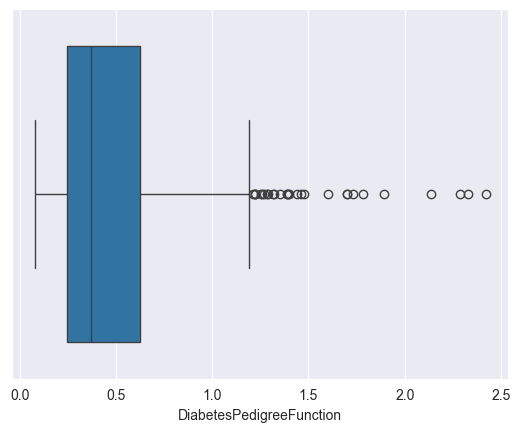

In [8]:
sns.boxplot(data=df, x="DiabetesPedigreeFunction")

<Axes: xlabel='Insulin'>

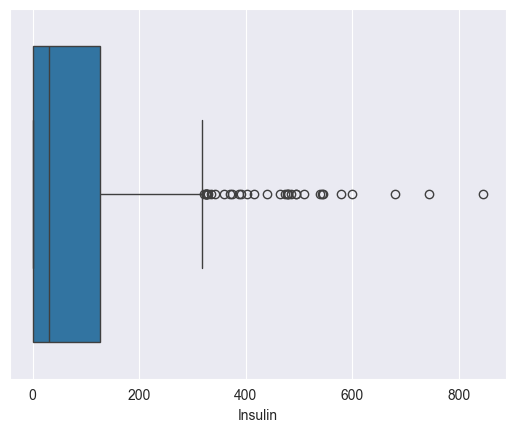

In [9]:
sns.boxplot(data=df, x="Insulin")

<Axes: xlabel='Glucose'>

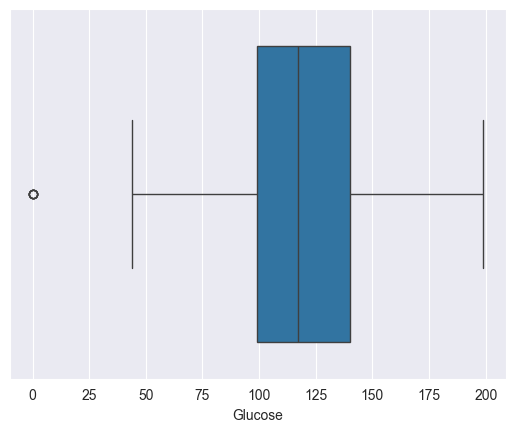

In [10]:
sns.boxplot(data=df, x="Glucose")

<Axes: xlabel='Pregnancies'>

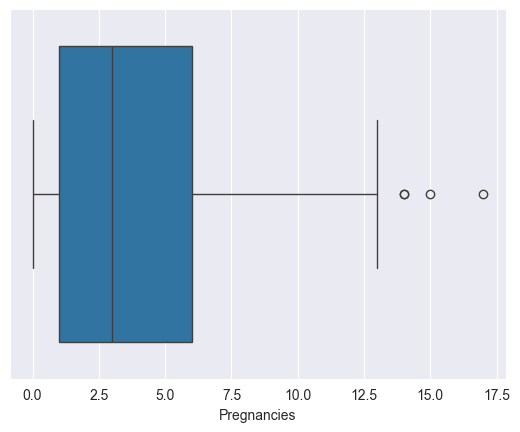

In [11]:
sns.boxplot(data=df, x="Pregnancies")

<Axes: xlabel='BloodPressure'>

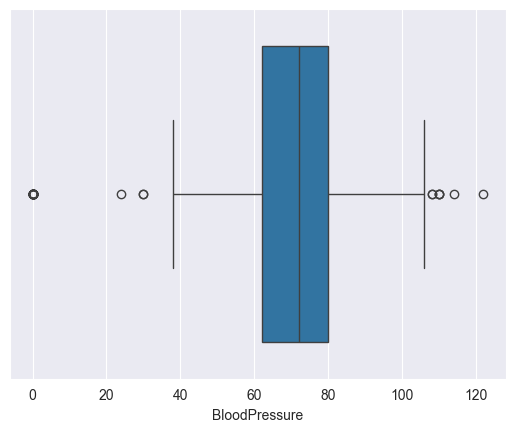

In [12]:
sns.boxplot(data=df, x="BloodPressure")

<Axes: xlabel='BMI'>

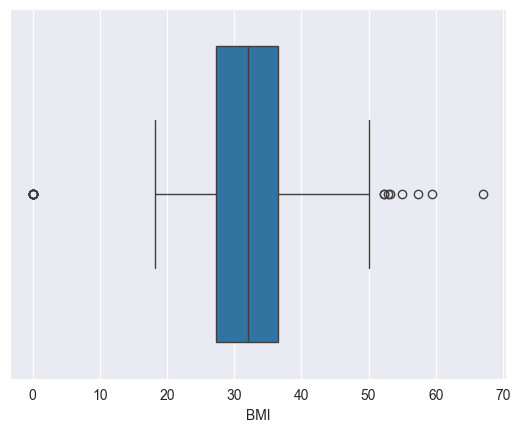

In [13]:
sns.boxplot(data=df, x="BMI")

In [14]:

for i in df[df['BloodPressure']==0]['BloodPressure'].index:
    df['BloodPressure'][i]=df['BloodPressure'].mean()
for i in df[df['SkinThickness']==0]['SkinThickness'].index:
    df['SkinThickness'][i]=df['SkinThickness'].mean()
for i in df[df['Insulin']==0]['Insulin'].index:
    df['Insulin'][i]=df['Insulin'].mean()
for i in df[df['BMI']==0]['BMI'].index:
    df['BMI'][i]=df['BMI'].mean()


In [15]:
df.iloc[7]

Pregnancies                  10.000000
Glucose                     115.000000
BloodPressure                69.105469
SkinThickness                20.589974
Insulin                      80.215914
BMI                          35.300000
DiabetesPedigreeFunction      0.134000
Age                          29.000000
Outcome                       0.000000
Name: 7, dtype: float64

<Axes: xlabel='SkinThickness'>

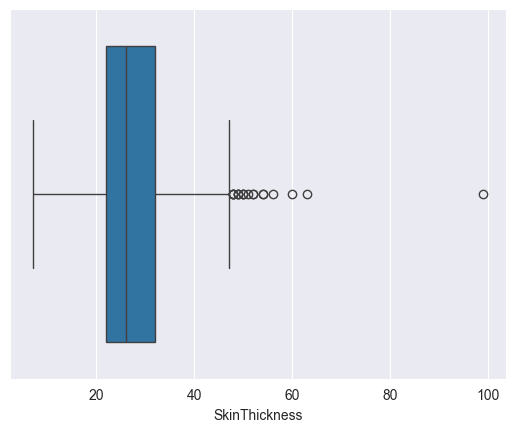

In [16]:
sns.boxplot(data=df, x="SkinThickness")

In [17]:
for i in df[df['Glucose']<2]['Glucose'].index:
    df['Glucose'][i]=df['Glucose'].mean()
df.describe() 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.683657,72.325527,27.593560,129.823960,32.453800,0.471876,33.240885,0.348958
std,3.369578,30.435978,12.103470,9.182155,89.597861,6.875237,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,22.000000,87.837043,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,26.000000,106.055607,32.264327,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,129.360248,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.128804       0.190368       0.036404   
Glucose                      0.128804  1.000000       0.243951       0.155734   
BloodPressure                0.190368  0.243951       1.000000       0.162324   
SkinThickness                0.036404  0.155734       0.162324       1.000000   
Insulin                      0.048758  0.428437       0.062615       0.305157   
BMI                          0.000659  0.225452       0.288551       0.546032   
DiabetesPedigreeFunction    -0.043242  0.090325       0.011032       0.085032   
Age                          0.607216  0.281417       0.369159       0.114324   
Outcome                      0.198689  0.481691       0.169744       0.186230   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies               0.048758  0.000659                 -0.043242   
Glucose                   0.428437  0.225

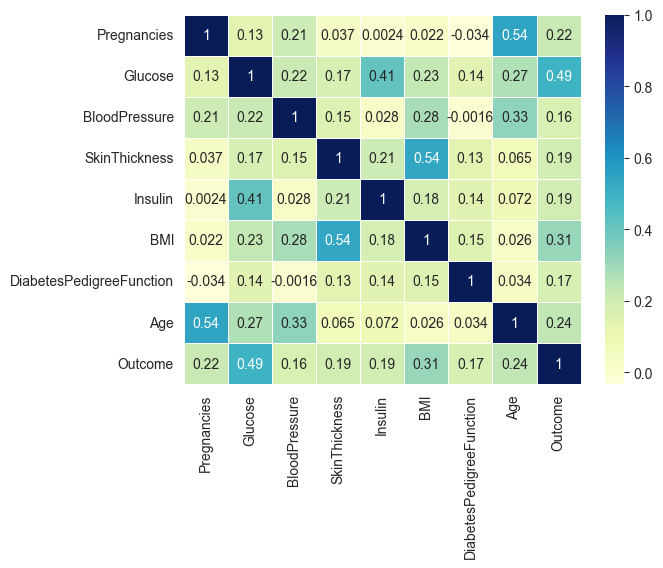

In [18]:
correlation = df.corr(method='pearson')
sns.heatmap(correlation, 
            xticklabels=correlation.columns,
            yticklabels=correlation.columns,
            cmap="YlGnBu",
            annot=True,
            linewidth=0.5)
spearman_correlation=df.corr(method='spearman')
print(spearman_correlation)
kendall_correlation=df.corr(method='kendall')
print(kendall_correlation)

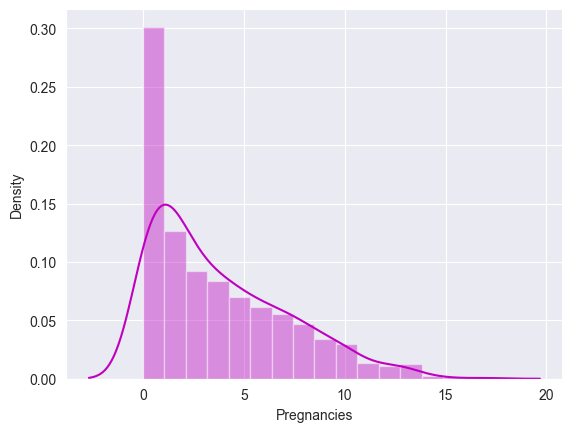

In [19]:
plot00=sns.distplot(df['Pregnancies'],color='m')

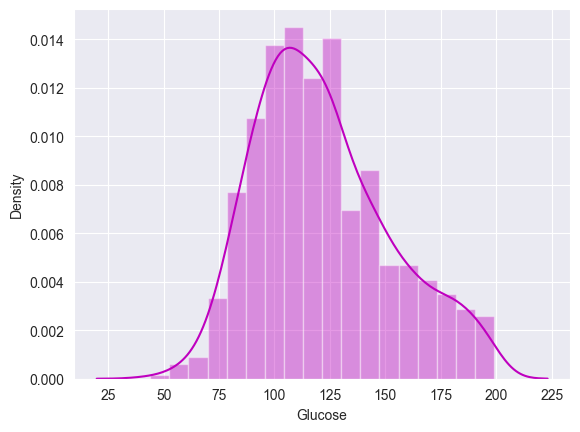

In [20]:
plot00=sns.distplot(df['Glucose'],color='m')

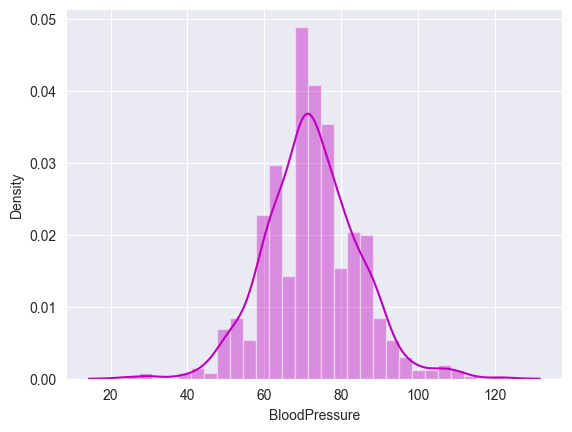

In [21]:
plot00=sns.distplot(df['BloodPressure'],color='m')

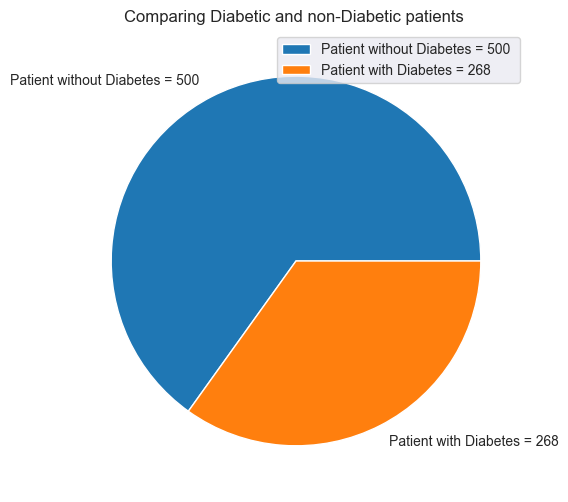

In [22]:
diabetes_count = np.array(df['Outcome'].value_counts(sort=True))
labels = ['Patient without Diabetes = 500 ', 'Patient with Diabetes = 268']
plt.figure(figsize=(8,6))
plt.pie(diabetes_count, labels=labels)
plt.legend()
plt.title('Comparing Diabetic and non-Diabetic patients ')
plt.show()

In [23]:
class_1=df[df['Outcome']==0]
class_2=df[df['Outcome']==1]

class_2_upsampled=resample(class_2,replace=True,n_samples=len(class_1),random_state=27)

upsampled=pd.concat([class_1,class_2_upsampled])
upsampled['Outcome'].value_counts()
data=upsampled


<Axes: xlabel='Outcome', ylabel='count'>

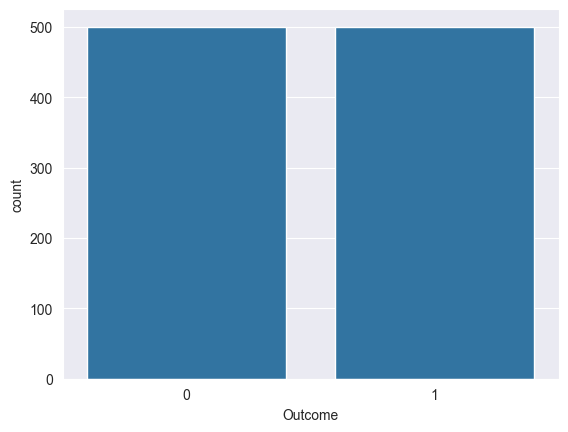

In [24]:
sns.countplot(data=data, x="Outcome")

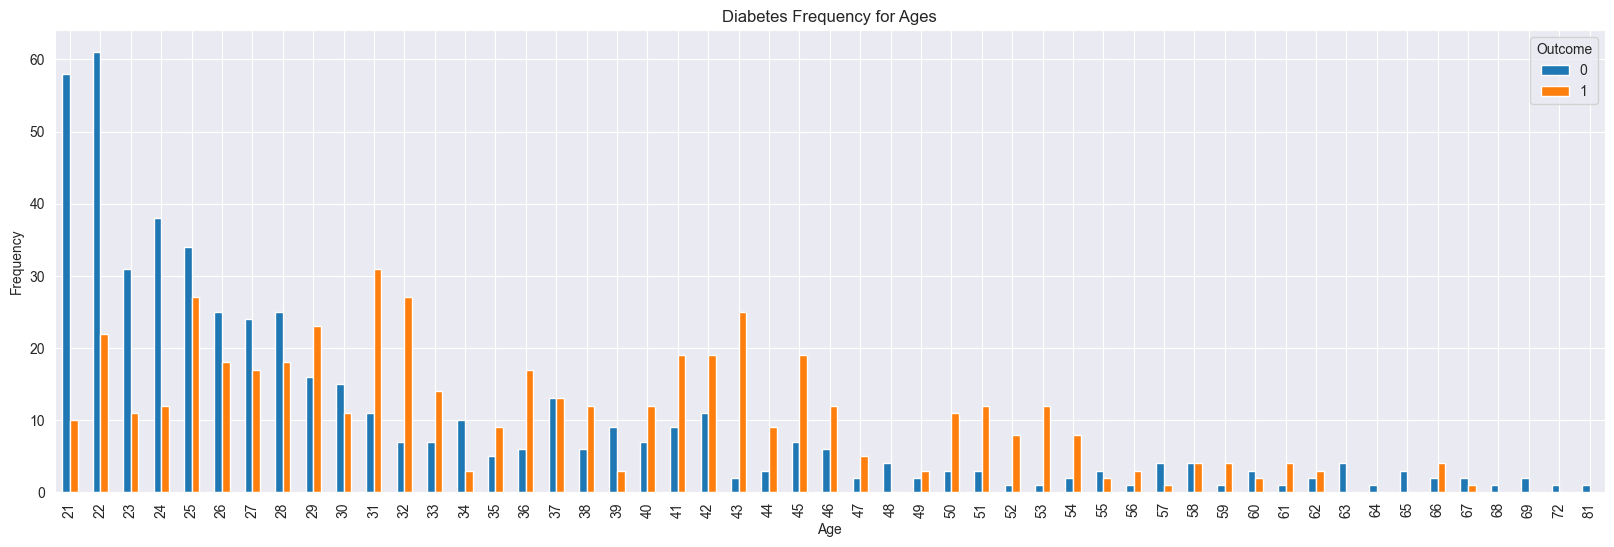

In [25]:

pd.crosstab(data.Age,data.Outcome).plot(kind="bar",figsize=(20,6))
plt.title('Diabetes Frequency for Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

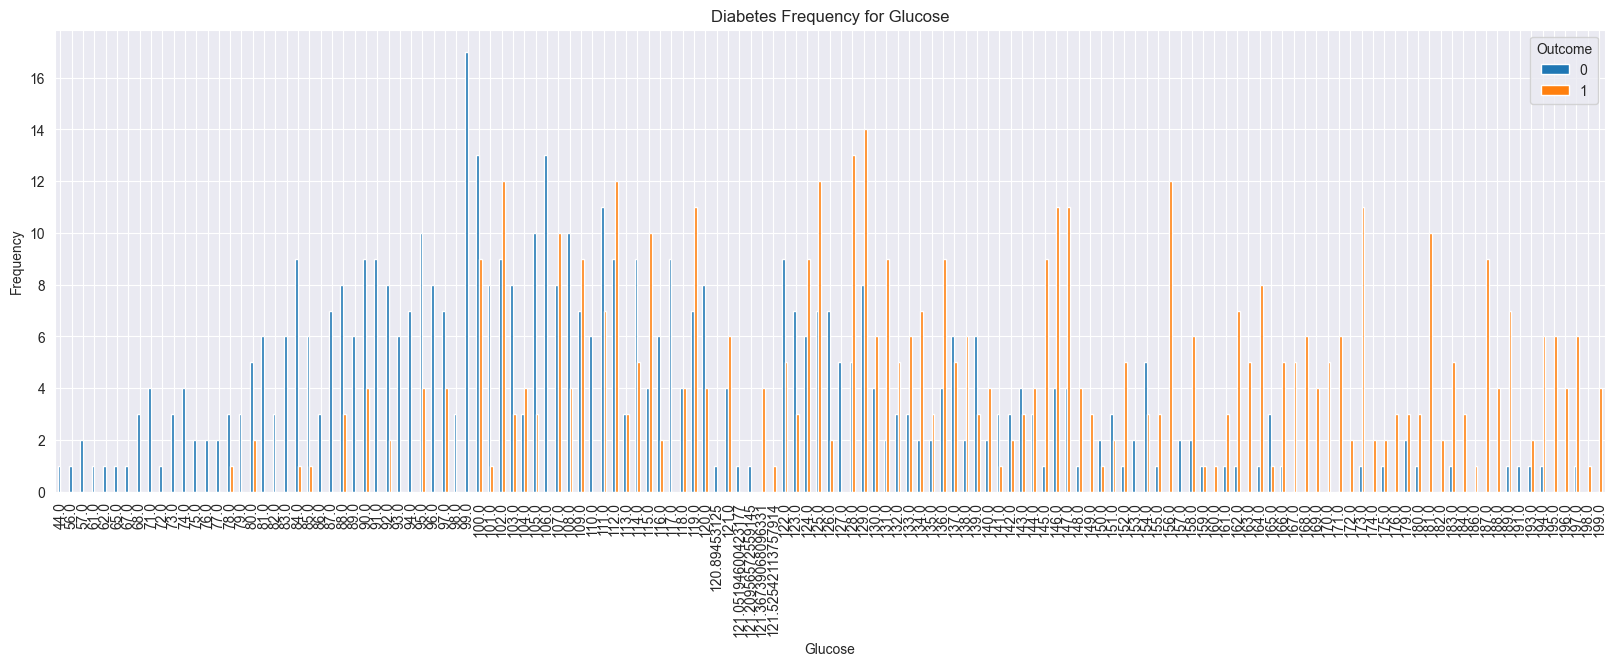

In [26]:
pd.crosstab(data.Glucose,data.Outcome).plot(kind="bar",figsize=(20,6))
plt.title('Diabetes Frequency for Glucose')
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.show()

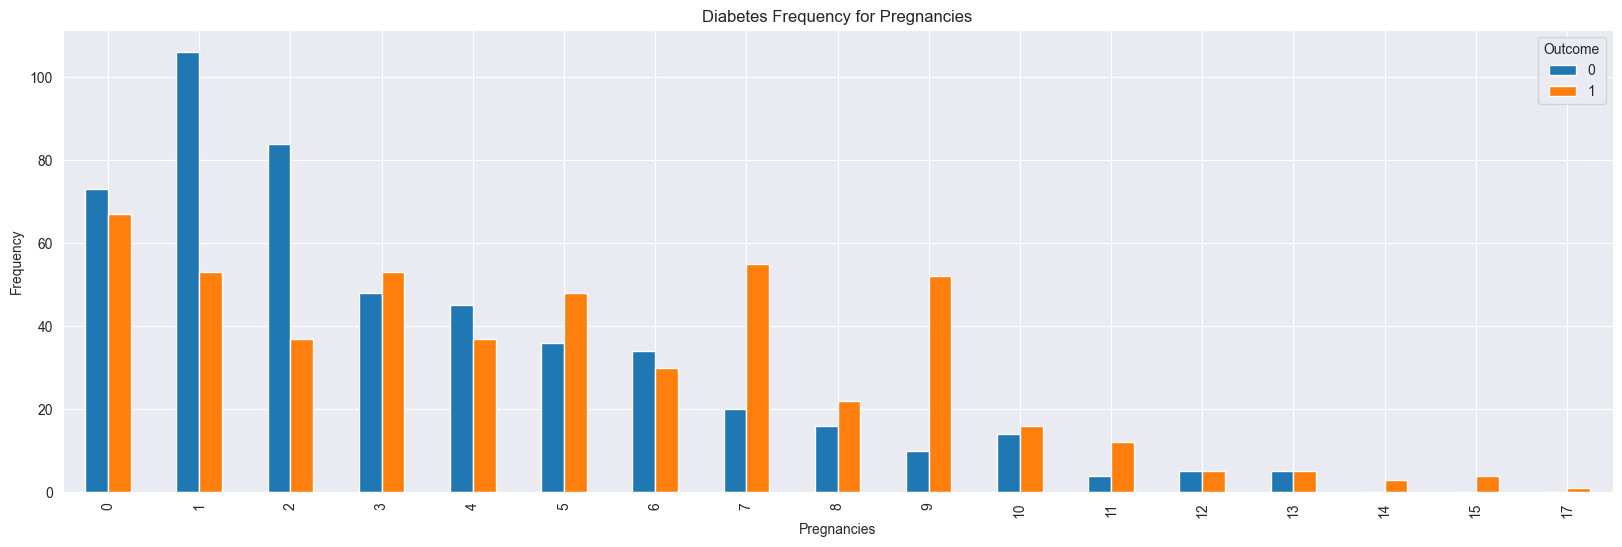

In [27]:
pd.crosstab(data.Pregnancies,data.Outcome).plot(kind="bar",figsize=(20,6))
plt.title('Diabetes Frequency for Pregnancies')
plt.xlabel('Pregnancies')
plt.ylabel('Frequency')
plt.show()

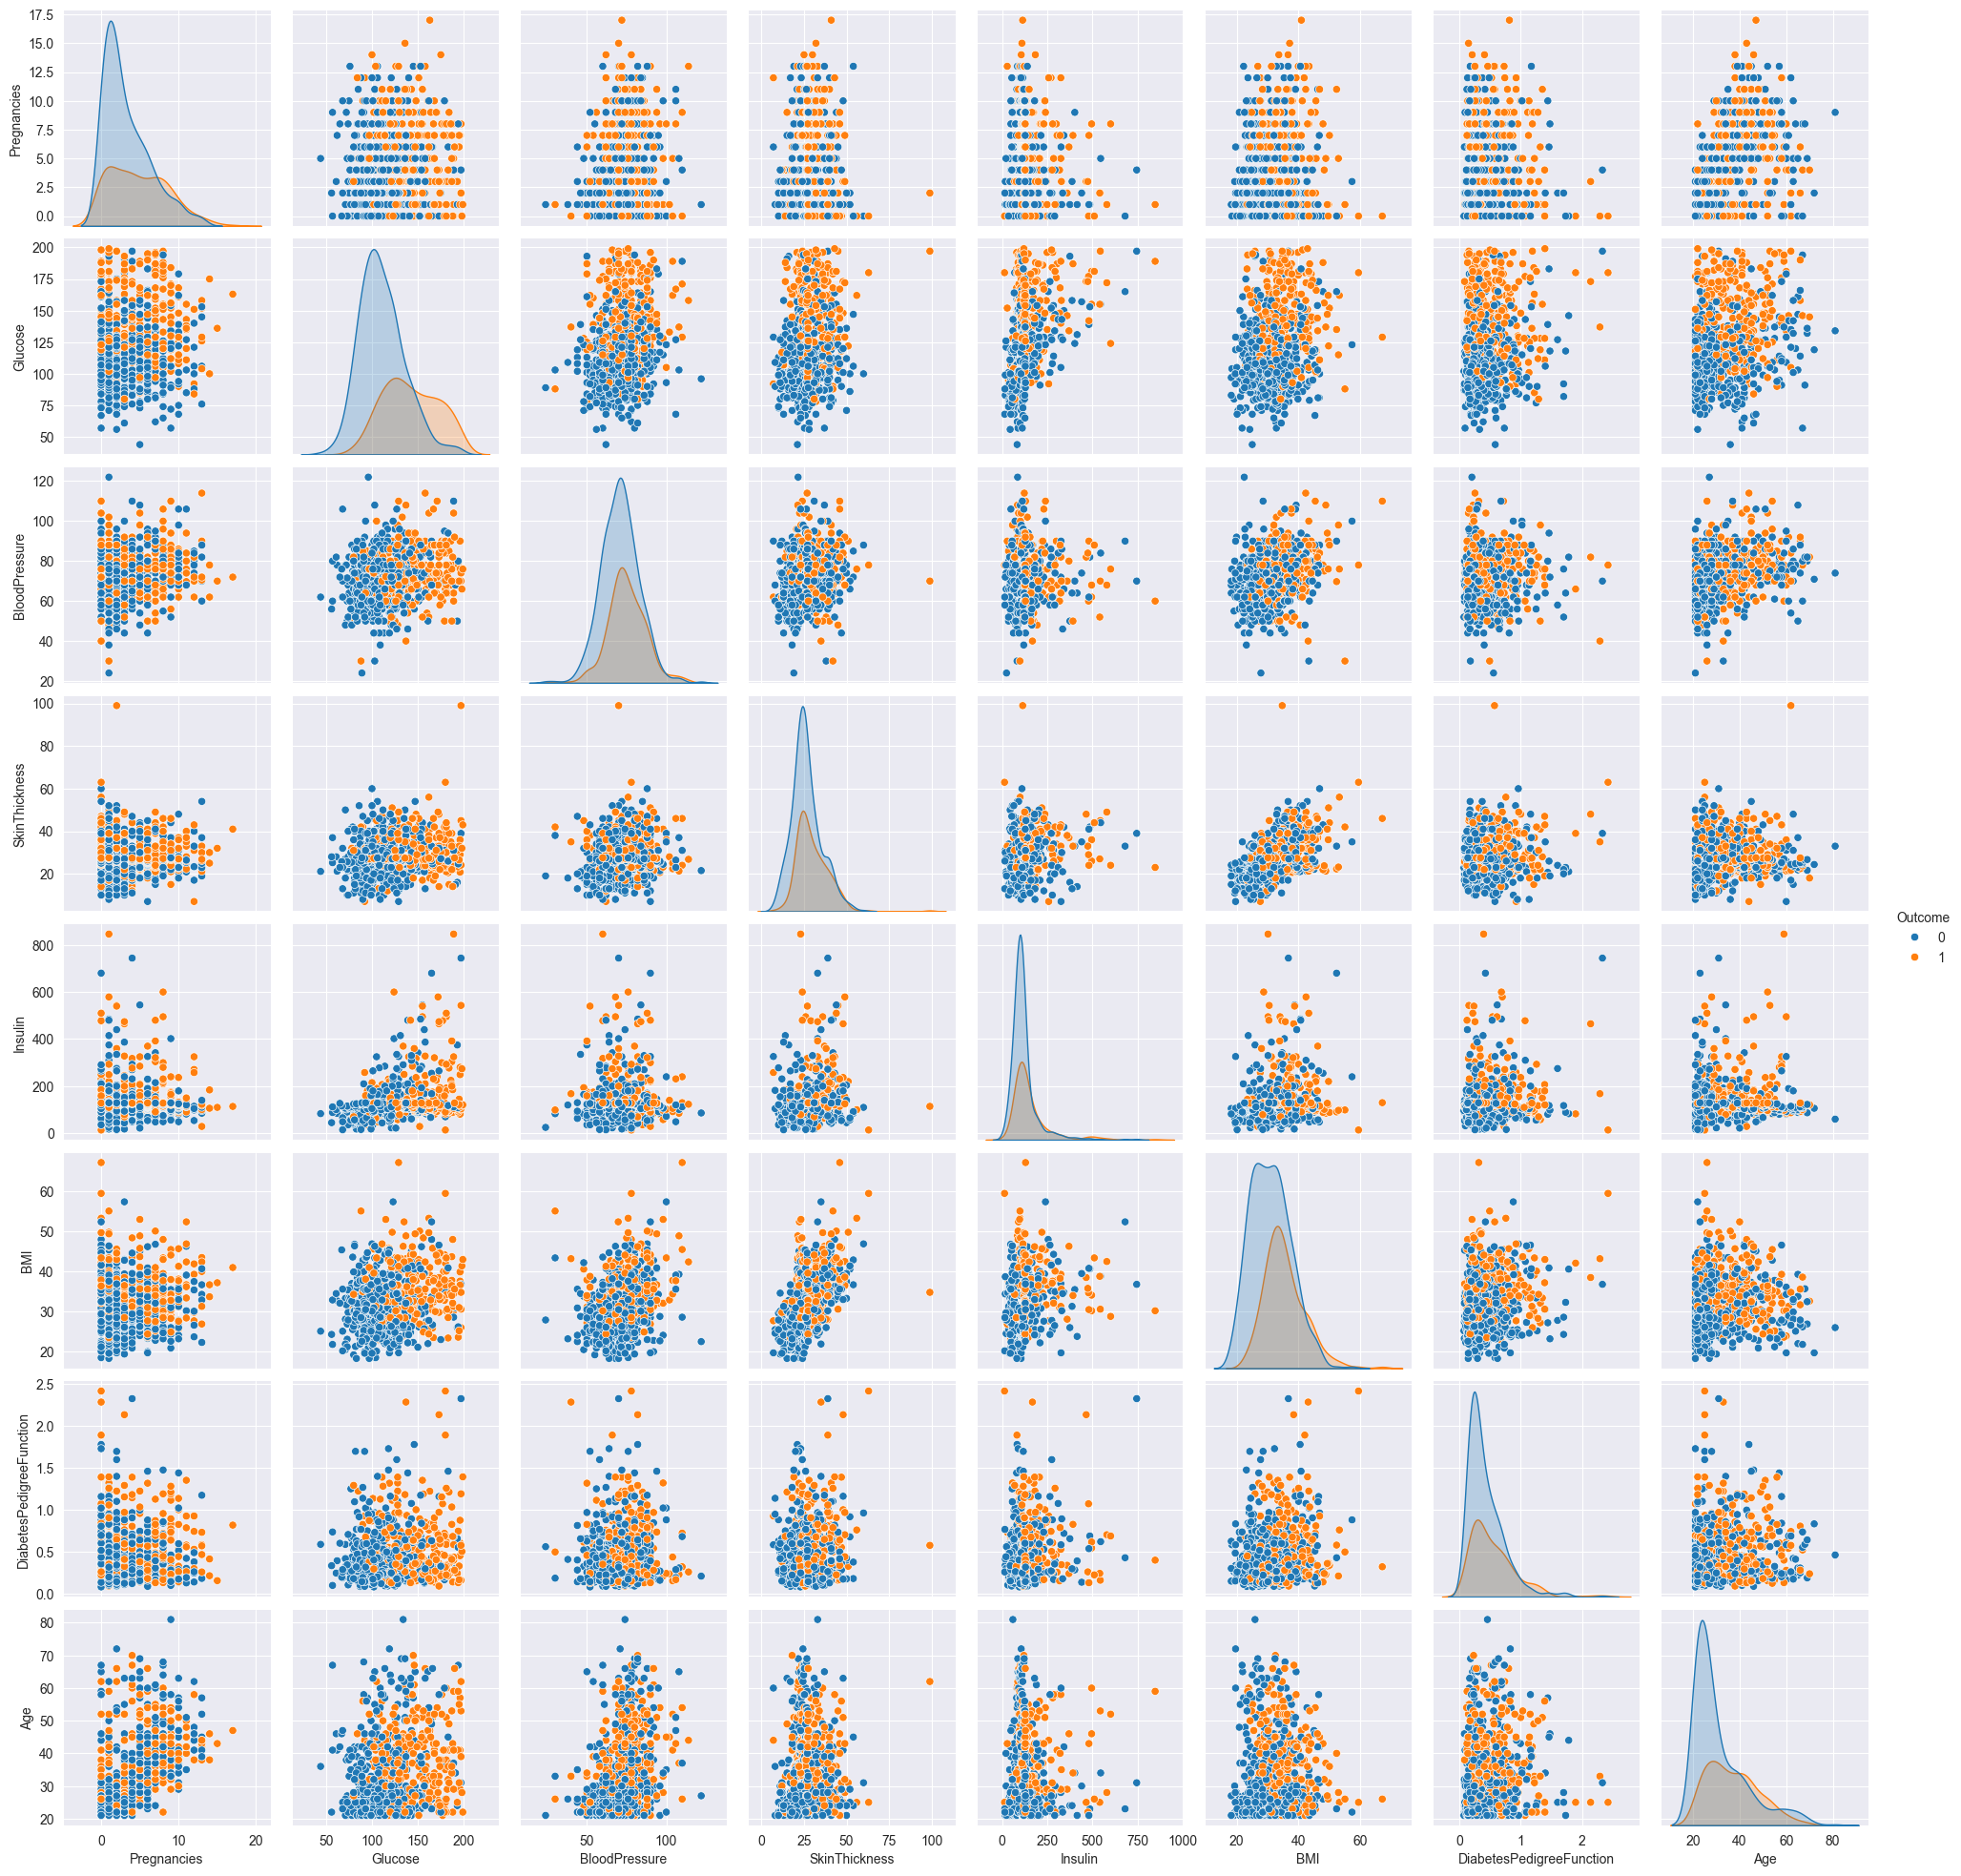

In [28]:
sns.pairplot(df, hue = 'Outcome')

In [29]:
scale = StandardScaler()

In [30]:

x = df.drop(['Outcome'], axis=1)
y = df['Outcome'].astype(float)
x=scale.fit_transform(x)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.20, random_state = 0)

Applying Hybrid model(Random forest and Gradiaent Boosting) without CSA

In [31]:
X = data.drop(['Outcome'], axis=1)
y = data['Outcome']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest and Gradient Boosting models
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
gb_clf = GradientBoostingClassifier(random_state=42)

rf_clf.fit(X_train, y_train)
gb_clf.fit(X_train, y_train)

# Get predictions from both models
rf_preds = rf_clf.predict_proba(X_test)[:, 1]
gb_preds = gb_clf.predict_proba(X_test)[:, 1]

# Combine predictions as features for the meta-classifier
stacked_features = np.column_stack((rf_preds, gb_preds))

# Train a meta-classifier (e.g., Logistic Regression)
meta_clf = LogisticRegression()
meta_clf.fit(stacked_features, y_test)

# Make final predictions
final_preds = meta_clf.predict(stacked_features)

# Evaluate the combined model
accuracy = accuracy_score(y_test, final_preds) * 100
precision = precision_score(y_test, final_preds)
recall = recall_score(y_test, final_preds)
f1 = f1_score(y_test, final_preds)

print("Accuracy for Combined Model (Random Forest + Gradient Boosting):", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy for Combined Model (Random Forest + Gradient Boosting): 88.0
Precision: 0.8703703703703703
Recall: 0.9038461538461539
F1 Score: 0.8867924528301887


Applying Hybrid model(Random forest and Gradiaent Boosting) with CSA

In [32]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [33]:
X = data.drop(['Outcome'], axis=1)
y = data['Outcome']
X = (X - np.min(X)) / (np.max(X) - np.min(X))

In [ ]:
# Define CSA for feature selection
class CSA:
    def __init__(self, num_features, num_crows, num_iterations, awareness_probability, flight_length):
        self.num_features = num_features
        self.num_crows = num_crows
        self.num_iterations = num_iterations
        self.awareness_probability = awareness_probability
        self.flight_length = flight_length
        self.memory = np.random.rand(num_crows, num_features)

    def run(self, X, y):
        best_features = None
        best_accuracy = 0

        for _ in range(self.num_iterations):
            for crow in range(self.num_crows):
                selected_features = self.select_features(crow)
                accuracy = self.evaluate_features(X[:, selected_features], y)

                if accuracy > best_accuracy:
                    best_accuracy = accuracy
                    best_features = selected_features

                self.update_memory(crow, selected_features, accuracy)

        return best_features

    def select_features(self, crow):
        if np.random.rand() < self.awareness_probability:
            return np.random.choice(range(self.num_features), size=int(self.num_features / 2), replace=False)
        else:
            return np.where(self.memory[crow] > 0.5)[0]

    def evaluate_features(self, X, y):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        model = RandomForestClassifier()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        return accuracy_score(y_test, y_pred)

    def update_memory(self, crow, selected_features, accuracy):
        for feature in selected_features:
            self.memory[crow, feature] = min(1, self.memory[crow, feature] + self.flight_length * accuracy)

In [35]:
# Run CSA for feature selection
csa = CSA(num_features=X.shape[1], num_crows=10, num_iterations=30, awareness_probability=0.1, flight_length=0.5)
selected_features = csa.run(X.values, y)

In [36]:
# Train Random Forest and Gradient Boosting on selected features
X_selected = X.iloc[:, selected_features]
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
gb_clf = GradientBoostingClassifier(random_state=42)

rf_clf.fit(X_train, y_train)
gb_clf.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [37]:
# Combine predictions using Logistic Regression
rf_preds = rf_clf.predict_proba(X_test)[:, 1]
gb_preds = gb_clf.predict_proba(X_test)[:, 1]
stacked_features = np.column_stack((rf_preds, gb_preds))

meta_clf = LogisticRegression()
meta_clf.fit(stacked_features, y_test)
final_preds = meta_clf.predict(stacked_features)

In [38]:
# Evaluate the combined model
accuracy = accuracy_score(y_test, final_preds) * 100
precision = precision_score(y_test, final_preds)
recall = recall_score(y_test, final_preds)
f1 = f1_score(y_test, final_preds)

print("Accuracy for Combined Model (Random Forest + Gradient Boosting) with CSA:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy for Combined Model (Random Forest + Gradient Boosting) with CSA: 89.0
Precision: 0.8867924528301887
Recall: 0.9038461538461539
F1 Score: 0.8952380952380953
